In [1]:

# !pip -q install statsmodels matplotlib pandas numpy scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.datasets import sunspots
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error


In [2]:
data = sunspots.load_pandas().data  # columns: YEAR, SUNACTIVITY
# Use YEAR as index (annual series)
y = data.set_index('YEAR')['SUNACTIVITY'].astype(float)
y.index.name = 'Year'
data.head()

,YEAR,SUNACTIVITY
0,1700.0,5.0
1,1701.0,11.0
2,1702.0,16.0
3,1703.0,23.0
4,1704.0,36.0


/tmp/ipython-input-871259775.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


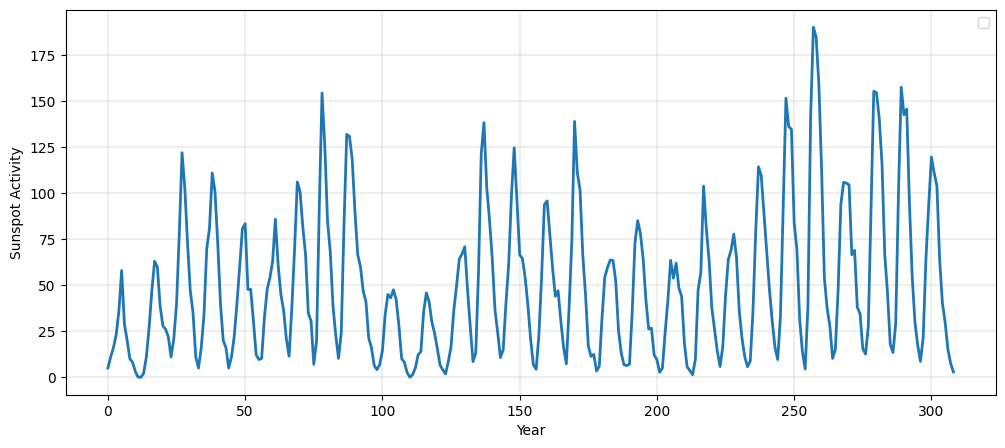

In [13]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data["SUNACTIVITY"], linewidth=2)


plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.legend()
plt.grid(True, linewidth=0.3)
plt.show()

In [4]:
# Make variance & mean more stationary
#    (log1p to handle zeros) + diff(1)
# ----------------------------------------
y_log = np.log1p(y)               # log(1 + y)
y_log_diff = y_log.diff().dropna()  # first difference

In [5]:
adf_stat, pval, usedlag, nobs, crit, icbest = adfuller(y_log_diff.values)
print("ADF Test on log-differenced series")
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value:       {pval:.4f}")
print("Critical values:", crit, "\n")

ADF Test on log-differenced series
ADF Statistic: -12.4871
p-value:       0.0000
Critical values: {'1%': np.float64(-3.4524113009049935), '5%': np.float64(-2.8712554127251764), '10%': np.float64(-2.571946570731871)} 



<Figure size 1200x400 with 0 Axes>

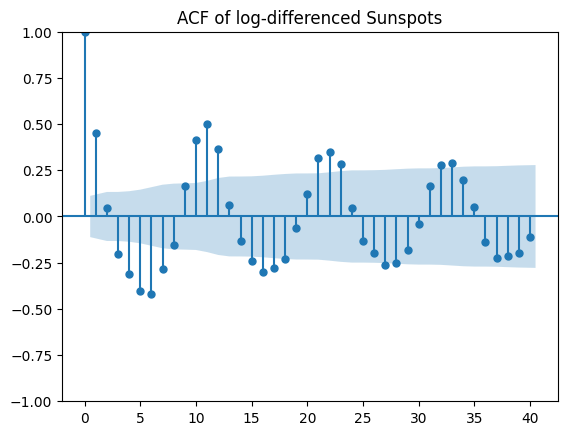

<Figure size 1200x400 with 0 Axes>

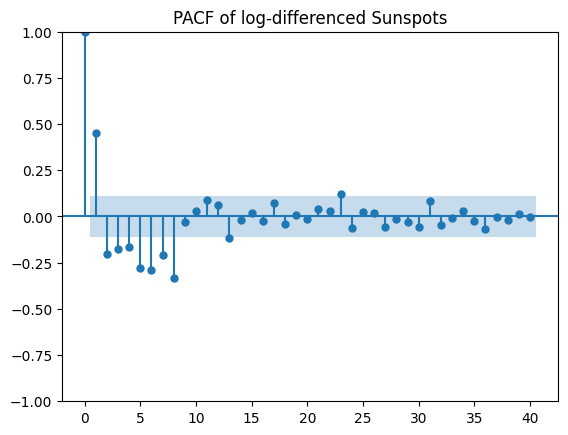

In [6]:
fig1 = plt.figure(figsize=(12,4))
plot_acf(y_log_diff, lags=40)
plt.title("ACF of log-differenced Sunspots")
plt.show()

fig2 = plt.figure(figsize=(12,4))
plot_pacf(y_log_diff, lags=40, method='ywm')
plt.title("PACF of log-differenced Sunspots")
plt.show()

In [7]:
test_horizon = 30  # forecast the last 30 years
train = y.iloc[:-test_horizon]
test  = y.iloc[-test_horizon:]

In [8]:
p=1
model = ARIMA(np.log1p(train), order=(p, 1, 0))
res = model.fit(method_kwargs={"warn_convergence": False})

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [9]:
fc_log = res.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [10]:
# Invert transform back to original scale
fc = np.expm1(fc_log)                   # inverse log1p

# Align forecast index to test index
fc.index = test.index

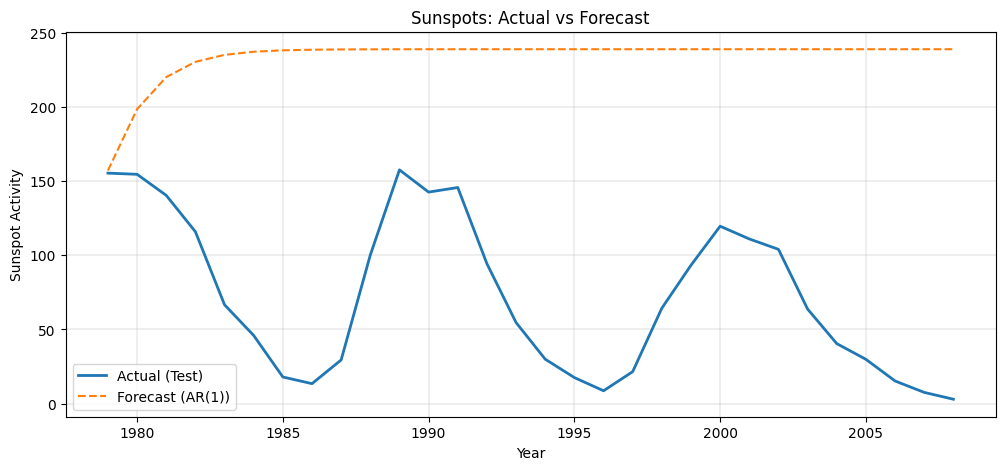

In [11]:
plt.figure(figsize=(12,5))
# plt.plot(train.index, train.values, label='Train', linewidth=2)
plt.plot(test.index,  test.values,  label='Actual (Test)', linewidth=2)
plt.plot(fc.index,    fc.values,    label=f'Forecast (AR({p}))', linestyle='--')
plt.title('Sunspots: Actual vs Forecast')
plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.legend()
plt.grid(True, linewidth=0.3)
plt.show()

In [12]:
mae = mean_absolute_error(test, fc)

# MAPE (handle zeros safely)
epsilon = 1e-8
mape = (np.abs((test.values - fc.values) / np.maximum(np.abs(test.values), epsilon))).mean() * 100

print(f"MAE  : {mae:.3f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 161.636
MAPE : 862.91%
